# Approximation Algorithms for Steiner Trees in Weighted Graphs

Nikola Labus — Naučno izračunavanje 2025/26

In [1]:
import networkx as nx
import time
from itertools import combinations
from pathlib import Path

## Analiza skupova podataka

Pregled strukture svih korišćenih benchmark setova: broj čvorova, grana, terminala, gustina grafa i distribucija težina grana.

=== Small (10 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
small01        5      7     3   0.7000      1      9     4.4
small02       10     15     4   0.3333      1      7     3.5
small03       15     25     5   0.2381      1     20     4.3
small04       20     40     6   0.2105      1     10     4.7
small05       25     50     7   0.1667      1     10     5.7
small06       26     52     7   0.1600      1     10     5.4
small07       27     54     7   0.1538      1     10     5.6
small08       28     56     8   0.1481      1     10     5.6
small09       29     58     8   0.1429      1     10     5.3
small10       30     60     8   0.1379      1     10     5.4

Prosek:       22     42     6   0.2391


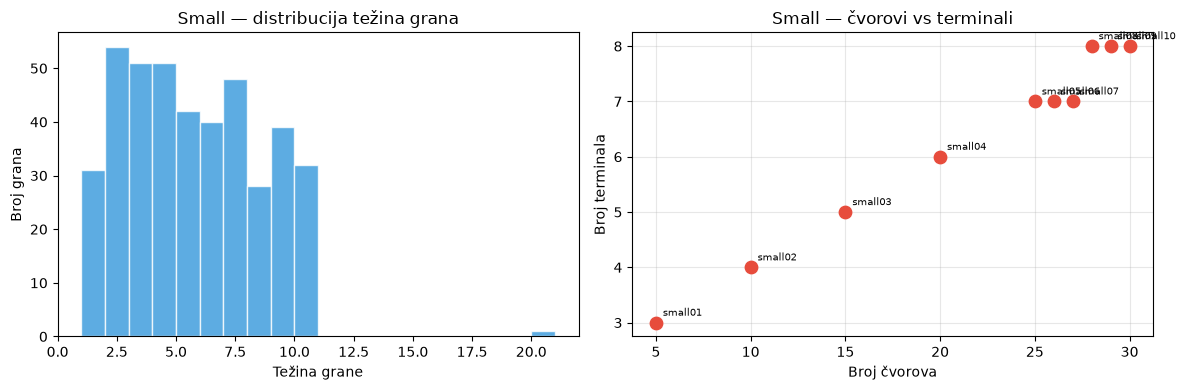

=== B (Beasley) (18 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
B01           50     63     9   0.0514      1     10     5.7
B02           50     63    13   0.0514      1     10     5.6
B03           50     63    25   0.0514      1     10     5.2
B04           50    100     9   0.0816      1     10     6.1
B05           50    100    13   0.0816      1     10     5.3
B06           50    100    25   0.0816      1     10     5.7
B07           75     94    13   0.0339      1     10     5.5
B08           75     94    19   0.0339      1     10     5.3
B09           75     94    38   0.0339      1     10     5.2
B10           75    150    13   0.0541      1     10     5.7
B11           75    150    19   0.0541      1     10     5.1
B12           75    150    38   0.0541      1     10     5.7
B13          100    125    17   0.0253      1     10     5.7
B14          100    125    25   0.0253      1     

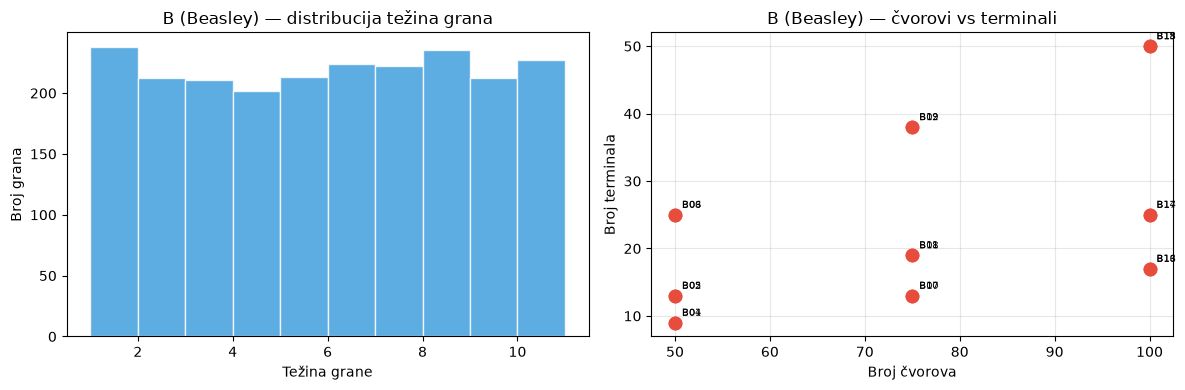

=== C (Beasley) (20 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
C01          500    625     5   0.0050      1     10     5.6
C02          500    625    10   0.0050      1     10     5.5
C03          500    625    83   0.0050      1     10     5.5
C04          500    625   100   0.0050      1     10     5.5
C05          500    625   100   0.0050      1     10     5.6
C06          500   1000     5   0.0080      1     10     5.5
C07          500   1000    10   0.0080      1     10     5.5
C08          500   1000    83   0.0080      1     10     5.4
C09          500   1000   100   0.0080      1     10     5.5
C10          500   1000   100   0.0080      1     10     5.5
C11          500   2500     5   0.0200      1     10     5.5
C12          500   2500    10   0.0200      1     10     5.5
C13          500   2500    83   0.0200      1     10     5.6
C14          500   2500   100   0.0200      1     

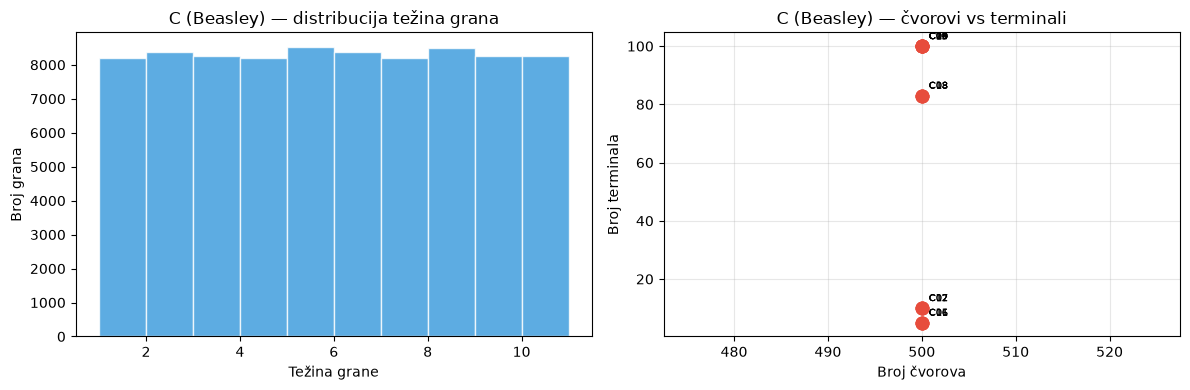

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import re

def analyze_dataset(dataset_path, dataset_name):
    """Prikazuje osnovne statistike za sve instance u datom datasetu."""
    files = sorted(Path(dataset_path).glob('*.stp'))
    if not files:
        print(f"Nema .stp fajlova u {dataset_path}")
        return

    stats = []
    all_weights = []

    for f in files:
        terminals = []
        n_nodes = 0
        n_edges = 0
        name = f.stem
        weights = []

        with open(f, 'r') as fp:
            section = None
            for line in fp:
                line = line.strip()
                if line.startswith('SECTION'):
                    section = line.split()[1]
                elif line in ('END', 'EOF'):
                    section = None
                elif section == 'Comment' and line.startswith('Name'):
                    name = line.split('"')[1]
                elif section == 'Graph':
                    if line.startswith('Nodes'):
                        n_nodes = int(line.split()[1])
                    elif line.startswith('Edges'):
                        n_edges = int(line.split()[1])
                    elif line.startswith('E '):
                        parts = line.split()
                        weights.append(int(parts[3]))
                elif section == 'Terminals' and line.startswith('T '):
                    terminals.append(int(line.split()[1]))

        max_edges = n_nodes * (n_nodes - 1) / 2
        density = n_edges / max_edges if max_edges > 0 else 0
        stats.append({
            'name': name, 'nodes': n_nodes, 'edges': n_edges,
            'terminals': len(terminals), 'density': density,
            'w_min': min(weights), 'w_max': max(weights),
            'w_avg': sum(weights) / len(weights)
        })
        all_weights.extend(weights)

    # Tabela
    print(f"=== {dataset_name} ({len(files)} instanci) ===\n")
    header = f"{'Instanca':<10} {'N':>5} {'E':>6} {'T':>5} {'Gustina':>8} {'w_min':>6} {'w_max':>6} {'w_avg':>7}"
    print(header)
    print('-' * len(header))
    for s in stats:
        print(f"{s['name']:<10} {s['nodes']:>5} {s['edges']:>6} {s['terminals']:>5}"
              f" {s['density']:>8.4f} {s['w_min']:>6} {s['w_max']:>6} {s['w_avg']:>7.1f}")

    # Sumarno
    avg_n = sum(s['nodes'] for s in stats) / len(stats)
    avg_e = sum(s['edges'] for s in stats) / len(stats)
    avg_t = sum(s['terminals'] for s in stats) / len(stats)
    avg_d = sum(s['density'] for s in stats) / len(stats)
    print(f"\nProsek:    {avg_n:>5.0f} {avg_e:>6.0f} {avg_t:>5.0f} {avg_d:>8.4f}")

    # Histogram težina grana
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(all_weights, bins=range(min(all_weights), max(all_weights) + 2),
                 color='#3498db', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Težina grane')
    axes[0].set_ylabel('Broj grana')
    axes[0].set_title(f'{dataset_name} — distribucija težina grana')

    # Scatter: čvorovi vs terminali
    nodes = [s['nodes'] for s in stats]
    terms = [s['terminals'] for s in stats]
    axes[1].scatter(nodes, terms, s=80, color='#e74c3c', zorder=5)
    for s in stats:
        axes[1].annotate(s['name'], (s['nodes'], s['terminals']),
                         textcoords="offset points", xytext=(5, 5), fontsize=7)
    axes[1].set_xlabel('Broj čvorova')
    axes[1].set_ylabel('Broj terminala')
    axes[1].set_title(f'{dataset_name} — čvorovi vs terminali')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Analiza sva tri dataseta
analyze_dataset('data/small', 'Small')
analyze_dataset('data/B', 'B (Beasley)')
analyze_dataset('data/C', 'C (Beasley)')

## STP Parser

In [2]:
def parse_stp(filepath):
    G = nx.Graph()
    terminals = []
    name = ""
    section = None

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('33D32945'):
                continue

            if line.startswith('SECTION'):
                section = line.split()[1]
                continue
            if line == 'END' or line == 'EOF':
                section = None
                continue

            if section == 'Comment':
                if line.startswith('Name'):
                    name = line.split('"')[1]

            elif section == 'Graph':
                if line.startswith('Nodes'):
                    n = int(line.split()[1])
                    G.add_nodes_from(range(1, n + 1))
                elif line.startswith('E '):
                    parts = line.split()
                    u, v, w = int(parts[1]), int(parts[2]), int(parts[3])
                    G.add_edge(u, v, weight=w)

            elif section == 'Terminals':
                if line.startswith('T '):
                    terminals.append(int(line.split()[1]))

    return G, terminals, name

## Brute Force (Egzaktan algoritam)

Prolazi kroz **sve podskupove neterminalnih čvorova** (od praznog do kompletnog):
1. Za svaki podskup formira indukovani podgraf: terminali + taj podskup
2. Proverava da li je podgraf povezan
3. Ako jeste — računa MST tog podgrafa i pamti težinu
4. Na kraju vraća MST sa najmanjom težinom

Složenost: **O(2ⁿ⁻ᵗ)** gde je n broj čvorova, t broj terminala. Na 30 čvorova sa 8 terminala to je 2²² ≈ 4 miliona podskupova — trajanje ~13 minuta.

In [3]:
def brute_force_steiner(G, terminals):
    terminal_set = set(terminals)
    non_terminals = [v for v in G.nodes() if v not in terminal_set]
    best_weight = float('inf')
    best_tree = None
    subsets_checked = 0

    for k in range(len(non_terminals) + 1):
        for subset in combinations(non_terminals, k):
            subsets_checked += 1
            nodes = terminal_set | set(subset)
            subgraph = G.subgraph(nodes)

            if nx.is_connected(subgraph):
                mst = nx.minimum_spanning_tree(subgraph)
                weight = mst.size(weight='weight')
                if weight < best_weight:
                    best_weight = weight
                    best_tree = mst

    return best_tree, best_weight, subsets_checked

## MST Heuristika (Kou, Markowsky, Berman, 1981)

**Aproksimacioni faktor: 2.** Koraci:
1. Za svaki par terminala (t₁, t₂) izračuna najkraći put u originalnom grafu (Dijkstra) i zapamti dužinu i put
2. Gradi **kompletni graf** samo od terminala, gde je težina grane = dužina najkraćeg puta
3. Na tom kompletnom grafu traži **MST** (minimalno razapinjuće stablo)
4. Svaku granu MST-a zamenjuje odgovarajućim najkraćim putem iz koraka 1 — ovo može uvesti cikluse
5. Na dobijenom podgrafu ponovo računa MST da ukloni cikluse
6. Iterativno briše listove koji nisu terminali (pruning)

Složenost: **O(t² · n log n)** — dominira t² Dijkstra poziva.

In [4]:
def mst_heuristic(G, terminals):
    complete = nx.Graph()
    paths = {}
    for i, t1 in enumerate(terminals):
        for t2 in terminals[i + 1:]:
            length, path = nx.single_source_dijkstra(G, t1, t2)
            complete.add_edge(t1, t2, weight=length)
            paths[(t1, t2)] = path


    mst = nx.minimum_spanning_tree(complete)

    steiner = nx.Graph()
    for u, v in mst.edges():
        key = (u, v) if (u, v) in paths else (v, u)
        path = paths[key]
        for j in range(len(path) - 1):
            w = G[path[j]][path[j + 1]]['weight']
            steiner.add_edge(path[j], path[j + 1], weight=w)

    steiner = nx.minimum_spanning_tree(steiner)

    changed = True
    while changed:
        changed = False
        leaves = [v for v in steiner.nodes() if steiner.degree(v) == 1 and v not in terminals]
        for leaf in leaves:
            steiner.remove_node(leaf)
            changed = True
    weight = steiner.size(weight='weight')
    return steiner, weight

## Mehlhorn algoritam (1988)

**Aproksimacioni faktor: 2.** Brža verzija MST heuristike korišćenjem Voronoi particije. Koraci:
1. Pokreće **multi-source Dijkstra** iz svih terminala odjednom — svaki čvor u grafu dobija labelu najbližeg terminala (Voronoi region) i rastojanje do njega
2. Za svaku granu (u, v) u originalnom grafu gde su u i v u **različitim** Voronoi regionima, računa težinu: dist(u, terminal₁) + w(u,v) + dist(v, terminal₂). Ovo je cena povezivanja dva regiona preko te grane
3. Gradi **međuregionalni graf** — čvorovi su terminali, grane su najjeftinije veze između regiona iz koraka 2
4. Na međuregionalnom grafu traži **MST**
5. Svaku granu MST-a rekonstruiše — zamenjuje putem od terminala kroz Voronoi region do granične grane i nazad
6. Na rezultujućem podgrafu ponovo računa MST + briše neterminalne listove

Složenost: **O(m log n)** — jedan Dijkstra prolaz umesto t² kao kod MST heuristike. Zato je 1000–5000× brži na velikim grafovima.

In [5]:
def mehlhorn_steiner(G, terminals):
    terminal_set = set(terminals)

    voronoi = {}
    dist = {}
    for v in G.nodes():
        dist[v] = 987654321

    for t in terminals:
        dist[t] = 0
        voronoi[t] = t

    import heapq
    pq = [(0,t) for t in terminals]
    heapq.heapify(pq)

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, data in G[u].items():
            w = data['weight']
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                voronoi[v] = voronoi[u]
                heapq.heappush(pq, (dist[v], v))

    region_graph = nx.Graph()
    for u, v, data in G.edges(data=True):
        r1 = voronoi[u]
        r2 = voronoi[v]
        if r1 != r2:
            edge_weight = dist[u] + data['weight'] + dist[v]
            if not region_graph.has_edge(r1, r2) or region_graph[r1][r2]['weight'] > edge_weight:
                region_graph.add_edge(r1, r2, weight= edge_weight, via_u=u, via_v=v)

    mst = nx.minimum_spanning_tree(region_graph)

    steiner = nx.Graph()
    for r1,r2,data in mst.edges(data=True):
        u = data['via_u']
        v = data['via_v']
        for node, terminal in [(u,r1), (v, r2)]:
            path = nx.shortest_path(G, terminal, node, weight='weight')
            for j in range(len(path) - 1):
                w = G[path[j]][path[j + 1]]['weight']
                steiner.add_edge(path[j], path[j + 1], weight=w)
        steiner.add_edge(u, v, weight=G[u][v]['weight'])

    steiner = nx.minimum_spanning_tree(steiner)

    changed = True
    while changed:
        changed = False
        leaves = [v for v in steiner.nodes() if steiner.degree(v) == 1 and v not in terminal_set]
        for leaf in leaves:
            steiner.remove_node(leaf)
            changed = True
    weight = steiner.size(weight='weight')
    return steiner, weight

## Shortest Path Heuristic — SPH (Takahashi, Matsuyama, 1980)

**Aproksimacioni faktor: 2.** Greedy algoritam koji gradi stablo dodavanjem jednog terminala u svakom koraku:
1. Počinje sa prvim terminalom kao stabom od jednog čvora
2. U svakoj iteraciji traži **najbliži nepokriven terminal** — za svaki preostali terminal računa Dijkstra rastojanje do svakog čvora koji je već u stablu
3. Dodaje najkraći put od stabla do tog terminala — svi čvorovi na putu ulaze u stablo
4. Ponavlja dok svi terminali nisu u stablu
5. Na kraju: MST na rezultujućem podgrafu + brisanje neterminalnih listova

Složenost: **O(t · |V_tree| · n log n)** — u svakoj od t iteracija radi Dijkstra iz svakog čvora stabla. Stablo raste pa je |V_tree| sve veći, zato je sporiji od MST heuristike na instancama sa mnogo terminala.

In [6]:
def sph_steiner(G, terminals):
    terminal_set = set(terminals)

    in_tree = {terminals[0]}
    remaining = set(terminals[1:])
    steiner = nx.Graph()

    while remaining:
        best_path = None
        best_length = 987654321
        best_terminal = None

        for t in remaining:
            for node in in_tree:
                try:
                    length, path = nx.single_source_dijkstra(G, node, t)
                    if length < best_length:
                        best_length = length
                        best_path = path
                        best_terminal = t
                except nx.NetworkXNoPath:
                    continue

        for j in range(len(best_path) - 1):
            w = G[best_path[j]][best_path[j + 1]]['weight']
            steiner.add_edge(best_path[j], best_path[j + 1], weight=w)

        in_tree.update(best_path)
        remaining.remove(best_terminal)

    steiner = nx.minimum_spanning_tree(steiner)

    changed = True
    while changed:
        changed = False
        leaves = [v for v in steiner.nodes() if steiner.degree(v) == 1 and v not in terminal_set]
        for leaf in leaves:
            steiner.remove_node(leaf)
            changed = True
    weight = steiner.size(weight='weight')
    return steiner, weight

## Zelikovsky algoritam (1993)

**Aproksimacioni faktor: 11/6 ≈ 1.83.** Poboljšava postojeće rešenje koristeći Steinerove tačke i trojke terminala:
1. Kreće od početnog rešenja dobijenog **MST heuristikom**
2. Preračunava sve najkraće puteve u originalnom grafu (all-pairs Dijkstra)
3. U svakoj iteraciji ispituje **sve trojke terminala** (t₁, t₂, t₃):
   - Računa cenu trenutnog povezivanja te trojke u stablu (zbir dve najduže grane trougla u stablu)
   - Za svaki neterminalni čvor v računa cenu **zvezde**: dist(v, t₁) + dist(v, t₂) + dist(v, t₃)
   - Ako je zvezda jeftinija — to je ušteda (saving)
4. Primenjuje trojku sa **najvećom uštedom**: dodaje puteve od Steinerove tačke do sva tri terminala
5. Ponovo računa MST + briše neterminalne listove
6. Ponavlja dok ima poboljšanja

Složenost: **O(t³ · n)** po iteraciji — tri ugneždene petlje po terminalima × petlja po neterminalima. Zato eksplodira na instancama sa 50+ terminala.

In [7]:
def zelikovsky_steiner(G, terminals):
    terminal_set = set(terminals)

    steiner, weight = mst_heuristic(G, terminals)

    all_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    all_paths = dict(nx.all_pairs_dijkstra_path(G, weight='weight'))
    non_terminals = [v for v in G.nodes() if v not in terminal_set]

    improved = True
    while improved:
        improved = False
        best_saving = 0
        best_triple = None
        best_steiner_node = None

        tree_dist = dict(nx.all_pairs_dijkstra_path_length(steiner, weight='weight'))

        for i, t1 in enumerate(terminals):
            for j in range(i + 1, len(terminals)):
                t2 = terminals[j]
                for k in range(j + 1, len(terminals)):
                    t3 = terminals[k]

                    try:
                        len_12 = tree_dist[t1][t2]
                        len_23 = tree_dist[t2][t3]
                        len_13 = tree_dist[t1][t3]
                    except KeyError:
                        continue

                    lengths = sorted([len_12, len_23, len_13], reverse=True)
                    current_cost = lengths[0] + lengths[1]

                    for v in non_terminals:
                        star_cost = all_dist[v][t1] + all_dist[v][t2] + all_dist[v][t3]
                        saving = current_cost - star_cost
                        if saving > best_saving:
                            best_saving = saving
                            best_triple = (t1, t2, t3)
                            best_steiner_node = v

        if best_saving > 0:
            t1, t2, t3 = best_triple
            v = best_steiner_node

            for t in [t1, t2, t3]:
                path = all_paths[v][t]
                for m in range(len(path) - 1):
                    w = G[path[m]][path[m + 1]]['weight']
                    steiner.add_edge(path[m], path[m + 1], weight=w)

            steiner = nx.minimum_spanning_tree(steiner)
            changed = True
            while changed:
                changed = False
                leaves = [node for node in steiner.nodes()
                          if steiner.degree(node) == 1 and node not in terminal_set]
                for leaf in leaves:
                    steiner.remove_node(leaf)
                    changed = True

            new_weight = steiner.size(weight='weight')
            if new_weight < weight:
                weight = new_weight
                improved = True

    return steiner, weight


## Zelikovsky + SPH baza

Identična logika kao Zelikovsky gore, ali u koraku 1 koristi **SPH** umesto MST heuristike kao početno rešenje.
SPH često daje lakše početno stablo, pa Zelikovsky ima manje posla — ali i manje prostora za poboljšanje.
Ukupno vreme je SPH + Zelikovsky iteracije, što ga čini najsporijim algoritmom.

In [8]:
def zelikovsky_sph(G, terminals):
    terminal_set = set(terminals)

    steiner, weight = sph_steiner(G, terminals)

    all_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    all_paths = dict(nx.all_pairs_dijkstra_path(G, weight='weight'))
    non_terminals = [v for v in G.nodes() if v not in terminal_set]

    improved = True
    while improved:
        improved = False
        best_saving = 0
        best_triple = None
        best_steiner_node = None

        tree_dist = dict(nx.all_pairs_dijkstra_path_length(steiner, weight='weight'))

        for i, t1 in enumerate(terminals):
            for j in range(i + 1, len(terminals)):
                t2 = terminals[j]
                for k in range(j + 1, len(terminals)):
                    t3 = terminals[k]

                    try:
                        len_12 = tree_dist[t1][t2]
                        len_23 = tree_dist[t2][t3]
                        len_13 = tree_dist[t1][t3]
                    except KeyError:
                        continue

                    lengths = sorted([len_12, len_23, len_13], reverse=True)
                    current_cost = lengths[0] + lengths[1]

                    for v in non_terminals:
                        star_cost = all_dist[v][t1] + all_dist[v][t2] + all_dist[v][t3]
                        saving = current_cost - star_cost
                        if saving > best_saving:
                            best_saving = saving
                            best_triple = (t1, t2, t3)
                            best_steiner_node = v

        if best_saving > 0:
            t1, t2, t3 = best_triple
            v = best_steiner_node

            for t in [t1, t2, t3]:
                path = all_paths[v][t]
                for m in range(len(path) - 1):
                    w = G[path[m]][path[m + 1]]['weight']
                    steiner.add_edge(path[m], path[m + 1], weight=w)

            steiner = nx.minimum_spanning_tree(steiner)
            changed = True
            while changed:
                changed = False
                leaves = [node for node in steiner.nodes()
                          if steiner.degree(node) == 1 and node not in terminal_set]
                for leaf in leaves:
                    steiner.remove_node(leaf)
                    changed = True

            new_weight = steiner.size(weight='weight')
            if new_weight < weight:
                weight = new_weight
                improved = True

    return steiner, weight

## Zelikovsky + Mehlhorn baza

Identična logika kao Zelikovsky, ali u koraku 1 koristi **Mehlhorn** umesto MST heuristike.
Mehlhorn je najbrži za početno rešenje (O(m log n)), ali njegova Voronoi struktura ponekad daje drugačiju topologiju stabla od MST heuristike — na nekim instancama to pomaže, na drugim odmaže.

In [9]:
def zelikovsky_mehlhorn(G, terminals):
    terminal_set = set(terminals)

    steiner, weight = mehlhorn_steiner(G, terminals)

    all_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    all_paths = dict(nx.all_pairs_dijkstra_path(G, weight='weight'))
    non_terminals = [v for v in G.nodes() if v not in terminal_set]

    improved = True
    while improved:
        improved = False
        best_saving = 0
        best_triple = None
        best_steiner_node = None

        tree_dist = dict(nx.all_pairs_dijkstra_path_length(steiner, weight='weight'))

        for i, t1 in enumerate(terminals):
            for j in range(i + 1, len(terminals)):
                t2 = terminals[j]
                for k in range(j + 1, len(terminals)):
                    t3 = terminals[k]

                    try:
                        len_12 = tree_dist[t1][t2]
                        len_23 = tree_dist[t2][t3]
                        len_13 = tree_dist[t1][t3]
                    except KeyError:
                        continue

                    lengths = sorted([len_12, len_23, len_13], reverse=True)
                    current_cost = lengths[0] + lengths[1]

                    for v in non_terminals:
                        star_cost = all_dist[v][t1] + all_dist[v][t2] + all_dist[v][t3]
                        saving = current_cost - star_cost
                        if saving > best_saving:
                            best_saving = saving
                            best_triple = (t1, t2, t3)
                            best_steiner_node = v

        if best_saving > 0:
            t1, t2, t3 = best_triple
            v = best_steiner_node

            for t in [t1, t2, t3]:
                path = all_paths[v][t]
                for m in range(len(path) - 1):
                    w = G[path[m]][path[m + 1]]['weight']
                    steiner.add_edge(path[m], path[m + 1], weight=w)

            steiner = nx.minimum_spanning_tree(steiner)
            changed = True
            while changed:
                changed = False
                leaves = [node for node in steiner.nodes()
                          if steiner.degree(node) == 1 and node not in terminal_set]
                for leaf in leaves:
                    steiner.remove_node(leaf)
                    changed = True

            new_weight = steiner.size(weight='weight')
            if new_weight < weight:
                weight = new_weight
                improved = True

    return steiner, weight
